In [1]:
import numpy as np
import os
import re
from matplotlib import pyplot as plt
from astropy.io import fits
# from astropy import stats
# import shutil
from astropy.visualization import simple_norm

from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
from scipy.ndimage import shift

from matplotlib.colors import LogNorm

from astropy.coordinates import SkyCoord
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from astroquery.ipac.ned import Ned
import astropy.units as u
from astropy.nddata import Cutout2D
# from scipy import interpolate
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
from IPython.display import clear_output
# from pyBBarolo import *
from scipy import stats
from scipy.interpolate import CubicSpline
from scipy.interpolate import interp1d

from matplotlib.patches import Rectangle, ConnectionPatch
import warnings
from astropy.wcs import WCS, FITSFixedWarning
from astropy.utils.data import get_pkg_data_filename

In [21]:
galaxy_name = "NGC1566"
dist = 20.3
pa = 222
i = 32

In [19]:
def create_radius_map(hdu, angle_map, dist = 20.3 , plot=False, incl=32): 
    # Create coordinate arrays centered on the reference pixel
    y = np.linspace(0, hdu.data.shape[0], hdu.data.shape[0]) - hdu.header["CRPIX2"]
    x = np.linspace(0, hdu.data.shape[1], hdu.data.shape[1]) - hdu.header["CRPIX1"]

    # Create 2D grid of X and Y coordinates
    X, Y = np.meshgrid(x, y)

    # Define a function to calculate Euclidean distance from the center
    def my_function(x, y):
        return np.sqrt(x**2 + y**2)

    # Vectorize the distance function for array operations
    my_vectorized_function = np.vectorize(my_function)
    distance_map_pix = my_vectorized_function(X, Y)
    print(f" data.shape = {distance_map_pix.shape}")  # Print shape of the pixel distance map

    # Convert pixel distances to physical distances using header scaling
    distance_map = dist * 1000 * np.tan(np.radians(distance_map_pix * hdu.header["CD2_2"]))*np.sqrt(1-(np.cos(angle_map/180.*np.pi)*np.radians(incl))**2)


    if plot:
        im = plt.imshow(distance_map, origin="lower", cmap="rainbow")
        plt.scatter(hdu.header["CRPIX1"], hdu.header["CRPIX2"], c="r")
        plt.contour(distance_map)
        plt.colorbar(im)
        plt.axis("off")
        plt.title("Radius Map (Kpc)")


    return distance_map

In [4]:
def create_angle_map(image_size, pa_deg, center_x, center_y):
    # Define the center of the image
    # center_x, center_y = image_size[0]//2, image_size[1]//2
    # Convert the position angle from degrees to radians

    
    pa_rad = np.radians(pa_deg)
    
    # Create a grid of coordinates for the image
    x = np.arange(image_size[1])
    y = np.arange(image_size[0])
    X, Y = np.meshgrid(x - center_x, y - center_y)  # Create coordinate grid centered at (0,0)
    
    # Calculate the angle for each pixel (in radians) relative to the center (0,0)
    angle_map = np.arctan2(Y, X)  # Angle in radians from the center
    
    # Adjust for the PA (rotate the angle to match the PA of the galaxy)
    angle_map += pa_rad - np.pi  # Apply the position angle offset
    
    # Normalize the angle to be within [0, 2π] range
    angle_map = np.mod(angle_map, 2 * np.pi)
    
    # Convert the angle map to degrees for easier interpretation
    angle_map_deg = np.degrees(angle_map)
    
    return angle_map_deg


In [ ]:
def compute_velocity_residuals(file, rad, circ_vel, Flux, dist, PA, incl, lim=50, interp="cubic", shift_vel=0, plot=False, save=False):
    """
    Calculate residual velocities between observed and model velocity fields.
    
    Computes the difference between observed velocity field from MUSE data and 
    a circular rotation model, accounting for galaxy inclination and position angle.
    
    Parameters
    ----------
    file : str
        Path to FITS file with observed velocity field
    rad : str
        Path to .npy file with radius values [arcsec]
    circ_vel : str
        Path to .npy file with circular velocity values [km/s]
    Flux : str
        Path to FITS file with observed flux
    dist : float
        Distance to galaxy [Mpc]
    PA : float
        Position angle of galaxy major axis [degrees]
    incl : float
        Inclination angle of galaxy [degrees]
    lim : float
        flux limit for weak pixel
    interp : str, optional
        Interpolation method: "cubic" or "linear", by default "cubic"
    shift_vel : float, optional
        Systemic velocity shift to apply [km/s], by default 0
    plot : bool, optional
        Whether to plot results, by default True
    
    Returns
    -------
    resid : numpy.ndarray
        2D array of velocity residuals [km/s]
    model_vel_map : numpy.ndarray
        2D array of model velocity field [km/s]
    hdu : astropy.io.fits.PrimaryHDU
        FITS HDU with original data
    """
    
    # Load observed velocity field from FITS file
    filename = get_pkg_data_filename(file)
    with fits.open(filename) as hdul:
        hdu = hdul[0]
    fluxname = get_pkg_data_filename(Flux)
    flux = fits.open(fluxname)[0]

    
    # Convert angular scale to physical scale [pc/arcsec]
    scale = np.pi * dist * 1000 / 180 / 3600
    
    # Create coordinate maps for deprojection
    angle_map = create_angle_map(
        hdu.data.shape, 
        PA, 
        hdu.header["CRPIX1"],  # reference pixel X
        hdu.header["CRPIX2"]   # reference pixel Y
    )
    distance_map = create_radius_map(hdu, angle_map)
    
    # Load and sort rotation curve data
    R = np.load(rad) * scale  # Convert to physical units [pc]
    V = np.load(circ_vel)     # Circular velocity [km/s]
    sort_idx = np.argsort(R)
    R_sorted = R[sort_idx]
    V_sorted = V[sort_idx]

    # Define interpolation methods
    interpolation_methods = {
        "cubic": lambda: CubicSpline(R_sorted, V_sorted),
        "linear": lambda: interp1d(R_sorted, V_sorted, kind='linear', 
                                  bounds_error=False, fill_value="extrapolate")
    }
    
    mask_bad = flux.data > lim
    # Select and create interpolator
    if interp in interpolation_methods:
        interpolator = interpolation_methods[interp]()
    else:
        raise ValueError(f"Unsupported interpolation: {interp}. "
                        f"Available methods: {list(interpolation_methods.keys())}")
    
    # Create 2D model velocity field
    radial_vel = interpolator(distance_map)  # Circular velocity at each point
    model_vel_map = radial_vel * np.cos(np.radians(angle_map))  # Project onto line of sight
    
    # Calculate residuals: observed - model
    observed_vel_projected = np.where(mask_bad, (hdu.data - shift_vel)/np.sin(np.radians(incl)), np.nan)
    resid = observed_vel_projected - model_vel_map
    
    # Alternative formulation (commented): deproject observed velocities first
    # resid = (hdu.data - shift_vel) / np.sin(np.radians(incl)) - model_vel_map

    # Generate diagnostic plots if requested
    if plot:
        _create_residual_plots(observed_vel_projected, model_vel_map, resid)

    if save:
        hdu.header['HISTORY'] = 'Residual velocities calculated'
        hdu.header['BUNIT'] = 'km/s'  # Единицы измерения

        # Ищем последовательность букв и цифр, которая начинается с NGC
        match = re.search(r"(NGC\d+)", file)
        if match:
            galaxy_name = match.group(1)
            print("Galaxy name:", galaxy_name)  # Вывод: NGC1566
        fits.writeto(f"data/{galaxy_name}/{galaxy_name}_residuals.fits", data=resid, header=hdu.header, overwrite=True)
        fits.writeto(f"data/{galaxy_name}/{galaxy_name}_circ_velocities_map.fits", model_vel_map, header=hdu.header, overwrite=True)
        fits.writeto(f"data/{galaxy_name}/{galaxy_name}_angle_map.fits", angle_map, header=hdu.header, overwrite=True)
        fits.writeto(f"data/{galaxy_name}/{galaxy_name}_distance_map.fits", distance_map, header=hdu.header, overwrite=True)
        print("Files saved.")  
        
    
    return resid, model_vel_map, hdu


def _create_residual_plots(observed_vel, model_vel, resid, vmax_obs=200, vmax_resid=50):
    """
    Create diagnostic plots for velocity residuals analysis.
    
    Parameters
    ----------
    observed_vel : numpy.ndarray
        Observed velocity field
    model_vel : numpy.ndarray
        Model velocity field  
    resid : numpy.ndarray
        Velocity residuals
    vmax_obs : float
        Colorbar limit for observed/model velocities
    vmax_resid : float
        Colorbar limit for residuals
    """
    
    plt.figure(figsize=[15, 5])
    
    # Plot 1: Observed velocity field
    plt.subplot(131)
    norm = simple_norm(observed_vel, "linear", percent=99.0)
    im = plt.imshow(observed_vel, cmap='coolwarm', origin='lower', norm=norm)
    im.set_clim(vmin=-vmax_obs, vmax=vmax_obs)
    plt.colorbar(im, label='km/s')
    plt.axis("off")
    plt.title(r"$V_{\mathrm{obs}}$")
    
    # Plot 2: Model velocity field
    plt.subplot(132)
    norm = simple_norm(model_vel, "linear", percent=99.0)
    im = plt.imshow(model_vel, cmap='coolwarm', origin='lower', norm=norm)
    im.set_clim(vmin=-vmax_obs, vmax=vmax_obs)
    plt.colorbar(im, label='km/s')
    plt.axis("off")
    plt.title(r"$V_{\mathrm{model}}$")
    
    # Plot 3: Residuals
    plt.subplot(133)
    norm = simple_norm(resid, "linear", percent=99.0)
    im = plt.imshow(resid, cmap="coolwarm", origin='lower', norm=norm)
    im.set_clim(vmin=-vmax_resid, vmax=vmax_resid)
    cb = plt.colorbar(im, label='km/s')
    plt.axis("off")
    plt.title("Residuals")
    
    plt.tight_layout()
    plt.show()




 data.shape = (1187, 898)


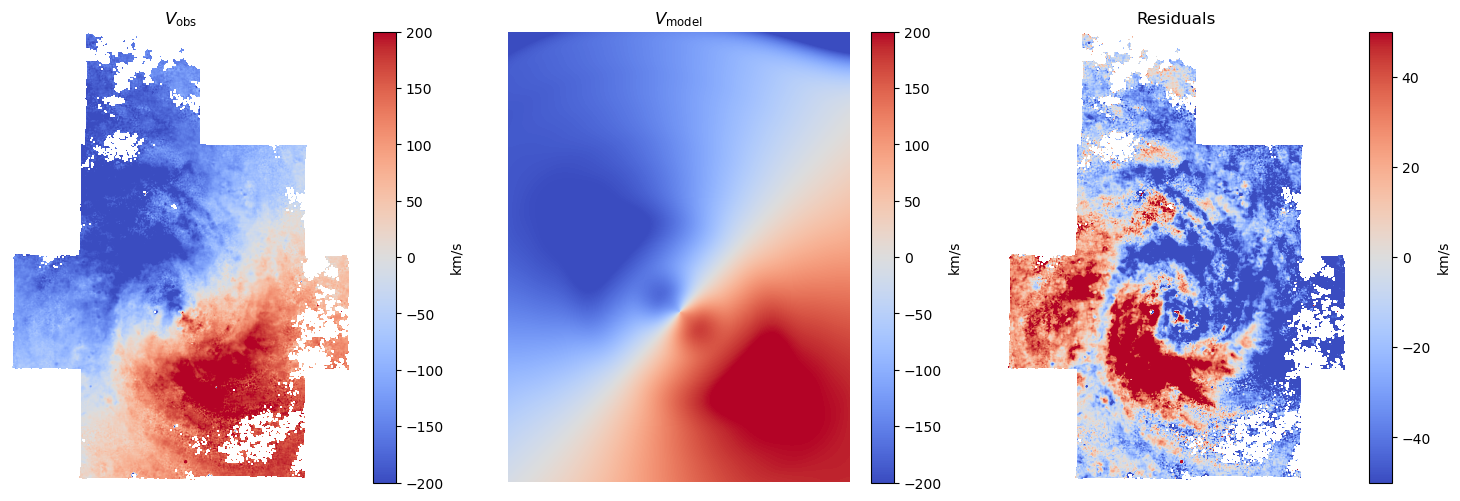

In [6]:
resid, vel_map, hdu = compute_velocity_residuals(f"data/{galaxy_name}_vel_Ha.fits", f"data/{galaxy_name}_rad.npy", f"data/{galaxy_name}_vel.npy", f"data/F_Ha.fits", dist, pa, i, 40, "cubic", shift_vel=29, plot=True, save=False)

In [7]:
def create_multiple_plots(*arrays, titles=None, cmaps='coolwarm', colorbar_labels='km/s', 
                         vmin_max=None, figsize_per_plot=5, norms='linear', 
                         percent=99.0, share_colorbar=False):
    """
    Create multiple plots for 2D arrays with flexible configuration.
    
    Parameters
    ----------
    *arrays : numpy.ndarray
        Variable number of 2D arrays to plot
    titles : list of str, optional
        Titles for each subplot. If None, will use default titles
    cmaps : str or list of str, optional
        Colormap(s) for plots. Can be single value or list per array
    colorbar_labels : str or list of str, optional
        Label(s) for colorbars. Can be single value or list per array
    vmin_max : tuple, list of tuples, or None, optional
        (vmin, vmax) for color scaling. Can be single tuple or list per array.
        If None, uses simple_norm with percent
    figsize_per_plot : float, optional
        Base size for calculating figure dimensions, by default 5
    norms : str or list of str, optional
        Normalization method(s), by default 'linear'
    percent : float, optional
        Percentile for simple_norm, by default 99.0
    share_colorbar : bool, optional
        Whether to use shared colorbar limits, by default False
    """
    
    n_plots = len(arrays)
    
    # Handle default values and convert to lists
    if titles is None:
        titles = [f'Array {i+1}' for i in range(n_plots)]
    elif isinstance(titles, str):
        titles = [titles] * n_plots
    
    if isinstance(cmaps, str):
        cmaps = [cmaps] * n_plots
    
    if isinstance(colorbar_labels, str):
        colorbar_labels = [colorbar_labels] * n_plots
    
    if isinstance(norms, str):
        norms = [norms] * n_plots
    
    # Handle vmin_max
    if vmin_max is None:
        vmin_max = [None] * n_plots
    elif isinstance(vmin_max, (tuple, list)) and len(vmin_max) == 2 and all(isinstance(x, (int, float)) for x in vmin_max):
        vmin_max = [vmin_max] * n_plots
    
    # Calculate figure size
    fig_width = n_plots * figsize_per_plot
    fig_height = figsize_per_plot
    
    fig, axes = plt.subplots(1, n_plots, figsize=(fig_width, fig_height))
    if n_plots == 1:
        axes = [axes]
    
    # Find global min/max if sharing colorbar
    if share_colorbar and vmin_max[0] is None:
        global_min = min(np.nanpercentile(arr, 100-percent) for arr in arrays)
        global_max = max(np.nanpercentile(arr, percent) for arr in arrays)
        vmin_max = [(global_min, global_max)] * n_plots
    
    images = []
    for i, (arr, ax, title, cmap, cb_label, norm_type, vmm) in enumerate(
            zip(arrays, axes, titles, cmaps, colorbar_labels, norms, vmin_max)):
        
        # Create normalization
        if vmm is None:
            norm = simple_norm(arr, norm_type, percent=percent)
            im = ax.imshow(arr, cmap=cmap, origin='lower', norm=norm)
        else:
            vmin, vmax = vmm
            im = ax.imshow(arr, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax)
        
        # Add colorbar
        cb = plt.colorbar(im, ax=ax)
        cb.set_label(cb_label)
        
        ax.axis('off')
        ax.set_title(title)
        images.append(im)
    
    plt.tight_layout()
    plt.show()
    
    return fig, axes, images

In [8]:

def plot_with_zoom(array, zoom_area, title=None, cmap=None, norm_type="log", 
                   log_a=50, percent=70, vmax=1, colorbar_label=r"$km \, s^{-1} pc^{-1}$",
                   figsize=(20, 10), draw_rectangle=True, draw_connections=True,
                   connection_corners_main=None, connection_corners_zoom=None):
    """
    Plot an array with a zoomed region and optional connecting lines.
    
    Parameters
    ----------
    array : numpy.ndarray
        2D array to plot
    zoom_area : tuple
        (xmin, ymin, xmax, ymax) defining the zoom region
    title : str, optional
        Title for the main plot
    cmap : str, optional
        Colormap for the plots
    norm_type : str, optional
        Normalization type for simple_norm, by default "log"
    log_a : int, optional
        Parameter for log normalization, by default 50
    percent : float, optional
        Percentile for normalization, by default 70
    vmax : float, optional
        Maximum value for color scaling, by default 1
    colorbar_label : str, optional
        Label for the colorbar, by default r"$km \, s^{-1} pc^{-1}$"
    figsize : tuple, optional
        Figure size, by default (20, 10)
    draw_rectangle : bool, optional
        Whether to draw rectangle around zoom area, by default True
    draw_connections : bool, optional
        Whether to draw connecting lines, by default True
    connection_corners_main : list, optional
        Custom corners for main image connections
    connection_corners_zoom : list, optional
        Custom corners for zoom image connections
    """
    
    fig, ax = plt.subplots(1, 2, figsize=figsize)
    
    # Create normalization
    norm = simple_norm(array, norm_type, log_a=log_a, percent=percent)
    
    # Main plot
    im = ax[0].imshow(array, norm=norm, origin="lower", cmap=cmap)
    im.set_clim(vmax=vmax)
    
    if title is None:
        ax[0].set_title(r"$\nabla V_{\varphi}$")
    else:
        ax[0].set_title(title)
    ax[0].axis("off")
    
    # Zoomed region
    zoomed = array[zoom_area[1]:zoom_area[3], zoom_area[0]:zoom_area[2]]
    im = ax[1].imshow(zoomed, norm=norm, origin="lower", cmap=cmap)
    cbar = plt.colorbar(im, ax=ax[1])
    cbar.set_label(colorbar_label, rotation=270)
    im.set_clim(vmax=vmax)
    ax[1].axis("off")
    ax[1].set_title("Zoomed Region")
    
    # Draw rectangle around zoom area
    if draw_rectangle:
        rect = Rectangle((zoom_area[0], zoom_area[1]), 
                        zoom_area[2] - zoom_area[0], 
                        zoom_area[3] - zoom_area[1],
                        linewidth=1, edgecolor='black', facecolor='none')
        ax[0].add_patch(rect)
    
    # Draw connecting lines
    if draw_connections:
        # Default corners if not provided
        if connection_corners_main is None:
            connection_corners_main = [
                (zoom_area[2], zoom_area[1]),  # правый нижний
                (zoom_area[2], zoom_area[3]),  # правый верхний
            ]
        
        if connection_corners_zoom is None:
            connection_corners_zoom = [
                (0, 0),                        # левый нижний
                (0, zoomed.shape[0])           # левый верхний
            ]
        
        # Draw connecting lines for all corners
        for (x1, y1), (x2, y2) in zip(connection_corners_main, connection_corners_zoom):
            con = ConnectionPatch(
                xyA=(x1, y1), coordsA=ax[0].transData,
                xyB=(x2, y2), coordsB=ax[1].transData,
                linestyle="--", linewidth=0.9, color="black",
                arrowstyle="-",
                mutation_scale=20
            )
            fig.add_artist(con)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax, zoomed
 

<>:5: SyntaxWarning: invalid escape sequence '\,'
<>:5: SyntaxWarning: invalid escape sequence '\,'
C:\Users\kpoli\AppData\Local\Temp\ipykernel_260\3157070343.py:5: SyntaxWarning: invalid escape sequence '\,'
  """


In [9]:
def apply_gradient_sign_by_angle(gradient_map, angle_map, phi1, phi2):
    """
    Умножает карту градиентов на -1 для пикселей, где угол попадает в диапазон [phi1, phi2]
    
    Parameters:
    -----------
    gradient_map : numpy.ndarray
        Карта градиентов скоростей
    angle_map : numpy.ndarray
        Карта углов в радианах
    phi1 : float
        Начальный угол диапазона (в радианах)
    phi2 : float
        Конечный угол диапазона (в радианах)
    
    Returns:
    --------
    numpy.ndarray
        Модифицированная карта градиентов
    """
    # Создаем копию исходной карты градиентов
    result_map = gradient_map.copy()
    
    # Создаем маску для углов в заданном диапазоне
    angle_mask = (angle_map >= phi1) & (angle_map <= phi2)
    
    # Применяем умножение на -1 для пикселей, попадающих в диапазон углов
    result_map[angle_mask] *= -1
    
    return result_map

In [10]:
def plot_three_panels_advanced(x, y1, y2, y3, angles, values, err=10,
                              titles=None, ylabels=None, colors=None,
                              figsize=(16, 9), xlim=(0, 360)):
    """
    Расширенная версия функции с дополнительными параметрами настройки
    """
    # Значения по умолчанию
    if titles is None:
        titles = ['F_Halpha', r'$V_{\varphi}$', r'$V_r$' ]
    if ylabels is None:
        ylabels = ['flux', 'km/s', 'km/s']
    if colors is None:
        colors = ['red', 'green', 'green']
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=figsize)
    axes = [ax1, ax2, ax3]
    y_data = [y1, y2, y3]
    
    for i, (ax, y, color) in enumerate(zip(axes, y_data, colors)):
        ax.set_yscale("symlog")
        ax.scatter(x, y, color=color, linewidth=0.5 + i*0.5)
        ax.set_title(titles[i], fontsize=14, pad=15)
        ax.set_ylabel(ylabels[i], fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(xlim[0], xlim[1])
        for a in angles[values>14000]:
            ax.axvspan(a-5, a+5, color='0.75', zorder=0)
        ax.hlines([0, err, -err], xmin=0, xmax=360, color="r", linewidth=1)
        
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    
    return fig, (ax1, ax2, ax3)


In [55]:
def slice_r_grad_median(grad, radius_map, angle_map, R=5, bound=0.1, med_deg=1, plot=True):
    # Создаем маску за одну операцию (векторизованно)
    mask = (radius_map > (R - bound/2)) & (radius_map < (R + bound/2))
    
    # Извлекаем значения по маске
    grad_1d = grad[mask]
    phase_1d = angle_map[mask]
    
    # Округляем до ближайшего четного числа (диапазон med_deg градуса)
    phase_rounded = np.round(phase_1d / med_deg).astype(int) * med_deg

    
    # Находим уникальные углы
    unique_phases = np.unique(phase_rounded)
    
    # Вычисляем медианное значение градиента для каждого угла
    grad_median = []
    phase_new = []
    
    for phase in unique_phases:
        # Маска для текущего угла
        phase_mask = (phase_rounded == phase)
        
        # Если есть точки с этим углом, вычисляем медиану
        if np.any(phase_mask):
            grad_median.append(np.median(grad_1d[phase_mask]))
            phase_new.append(phase)

    # Создаем маску для отрицательных медианных градиентов
    negative_mask = np.array(grad_median) < 0
    
    return np.array(grad_median), np.array(phase_new)
    

def slice_r_grad(arr, radius_map, angle_map, R=5, bound=0.1):
    # Создаем маску за одну операцию (векторизованно)
    mask = (radius_map > (R - bound/2)) & (radius_map < (R + bound/2))
    
    # Извлекаем значения по маске
    grad_1d = arr[mask]
    phase_1d = angle_map[mask]
    
    # Создаем маску для отрицательных градиентов
    negative_mask = grad_1d < 0
        
    return grad_1d, phase_1d

In [ ]:
def calc_grad_xy(file, dist, plot=True, zoom=False, save=False):
    filename = get_pkg_data_filename(file)
    with fits.open(filename) as hdul:
        hdu = hdul[0]
    pix_pc = dist*10**(6)*np.pi/180* hdu.header["CD2_2"]
    
    # Convert angular scale to physical scale [pc/arcsec]
    scale = np.pi * dist * 1000 / 180 / 3600
    vel_grad_xy = np.zeros_like(hdu.data)
    
    for i in range(hdu.data.shape[0]-1):
        for j in range(hdu.data.shape[1]-1):
            vel_grad_xy[i, j] = 1/2*np.sqrt((np.abs(hdu.data[i,j]-hdu.data[i,j+1]) + np.abs(hdu.data[i,j]-hdu.data[i,j-1]))**2 + (np.abs(hdu.data[i,j]-hdu.data[i+1,j]) + np.abs(hdu.data[i,j]-hdu.data[i+1,j]))**2)


    if plot:
        create_multiple_plots(hdu.data, vel_grad_xy/pix_pc, vmin_max=[[-150, 150],[0, 1]], titles=["vel", r"$\nabla V_{xy}$"], cmaps="viridis")
    if zoom:
        plot_with_zoom(vel_grad_xy/pix_pc, (400, 350, 650, 550), norm_type="linear", title=r"$V_{xy}$")

    if save:
        hdu.header['HISTORY'] = 'Velocities gradient XY calculated'
        hdu.header['BUNIT'] = 'km/s/pc'  # Единицы измерения

        # Ищем последовательность букв и цифр, которая начинается с NGC
        match = re.search(r"(NGC\d+)", file)
        if match:
            galaxy_name = match.group(1)
            print("Galaxy name:", galaxy_name)  # Вывод: {galaxy_name}
        fits.writeto(f"data/{galaxy_name}/{galaxy_name}_vel_grad_xy.fits", data=vel_grad_xy / pix_pc, header=hdu.header, overwrite=True)
        print("Files saved.")  
    return vel_grad_xy / pix_pc 



def calc_grad_r_phi(file_v, file_d, file_a, dist, size=3, plot=True, save=False, slice=True):
    """
    Вычисляет градиенты скорости на основе разностей в подмассивах ixi.
    
    Parameters:
    -----------
    velocity : numpy.ndarray (n x m)
        Массив скоростей.
    distance : numpy.ndarray (n x m)
        Массив расстояний.
    angle : numpy.ndarray (n x m)
        Массив углов.
    
    Returns:
    --------
    grad_r : numpy.ndarray (n x m)
        Радиальный градиент (разность скоростей в точках max и min расстояния).
    grad_phi : numpy.ndarray (n x m)
        Азимутальный градиент (разность скоростей в точках max и min угла).
    """
    
    files = [file_v, file_d, file_a]
    velocity, distance, angle = [fits.open(get_pkg_data_filename(f))[0].data for f in files]
    # n, m = velocity.shape
    head = fits.open(get_pkg_data_filename(file_v))[0].header
    # print(n,m)
    pix_pc = dist*10**(6)*np.pi/180* head["CD2_2"]

    grad_r = np.zeros_like(velocity)
    grad_phi = np.zeros_like(velocity)
    # print(distance[500:520, 500:520])
    # Проходим по каждому пикселю, кроме граничных (чтобы избежать выхода за границы)
    for i in range(size//2, velocity.shape[0] - size//2 - 1):
        for j in range(size//2, velocity.shape[1] - size//2 - 1):
            # Вырезаем подмассивы 3x3 (и тд)
            vel_patch = velocity[i-size//2:i+1+size//2, j-size//2:j+1+size//2]
            dist_patch = distance[i-size//2:i+size//2 +1, j-size//2:j+1+size//2]
            angle_patch = angle[i-size//2:i+1+size//2, j-size//2:j+1+size//2]
  
            # Находим индексы min и max расстояния
            min_dist_idx = np.unravel_index(np.argmin(dist_patch), dist_patch.shape)
            max_dist_idx = np.unravel_index(np.argmax(dist_patch), dist_patch.shape)
            
            # Находим индексы min и max угла
            min_angle_idx = np.unravel_index(np.argmin(angle_patch), angle_patch.shape)
            max_angle_idx = np.unravel_index(np.argmax(angle_patch), angle_patch.shape)
            
            # Вычисляем разности скоростей
            grad_r[i, j] = vel_patch[max_dist_idx] - vel_patch[min_dist_idx]
            grad_phi[i, j] = vel_patch[max_angle_idx] - vel_patch[min_angle_idx]
    
    grad_phi_sign = apply_gradient_sign_by_angle(grad_phi, angle, 90, 270)
    grad_r_sign = apply_gradient_sign_by_angle(grad_r, angle, 180, 360)

    if plot:
        create_multiple_plots(grad_r_sign/pix_pc, grad_phi_sign/pix_pc, vmin_max=[[-1, 1],[-1, 1]], cmaps="viridis", titles=[r"$\nabla V_r$", r"$\nabla V_{\phi}$"])
    if slice:
       slice_r_grad(grad_phi_sign, distance, angle)

    if save:
        # Ищем последовательность букв и цифр, которая начинается с NGC
        match = re.search(r"(NGC\d+)", file_v)
        if match:
            galaxy_name = match.group(1)
            print("Galaxy name:", galaxy_name)  # Вывод: {galaxy_name}

        head['HISTORY'] = 'Velocities radial gradient calculated'
        head['BUNIT'] = 'km/s/pc'  # Единицы измерения
        
        fits.writeto(f"data/{galaxy_name}/{galaxy_name}_vel_grad_r.fits", data=grad_r_sign/pix_pc, header=head, overwrite=True)
        head['HISTORY'] = 'Velocities azimuthal gradient calculated'
        
        fits.writeto(f"data/{galaxy_name}/{galaxy_name}_vel_grad_phi.fits", data=grad_phi_sign/pix_pc, header=head, overwrite=True)
        print("Files saved.")  

    return grad_r_sign/pix_pc, grad_phi_sign/pix_pc



In [57]:
from scipy.signal import argrelextrema

def find_local_maxima_scipy(x, y, order=1):
    """
    Поиск локальных максимумов с помощью SciPy
    
    Parameters:
    order: int - сколько точек с каждой стороны сравнивать
    """
    # Находим индексы локальных максимумов
    local_max_indices = argrelextrema(y, np.greater, order=order)[0]
    
    local_max_angles = x[local_max_indices]
    local_max_values = y[local_max_indices]
    
    return local_max_indices, local_max_angles, local_max_values


In [14]:
def azimuthal_scan(Flux, grad1, grad2, angle_map, distance_map, dist=20.3, R=5, bound=0.01):
       
    files = [Flux, grad1, grad2, angle_map, distance_map]
    flux, grad_r, grad_phi, angle, distance  = [fits.open(get_pkg_data_filename(f))[0].data for f in files]
    pix_pc = dist*10**(6)*np.pi/180* fits.open(get_pkg_data_filename(Flux))[0].header["CD2_2"]
       
    F, x= slice_r_grad(flux, distance, angle, R, bound)
    indices, angles, values = find_local_maxima_scipy(x, F, order=1)
    v_phi, _ = slice_r_grad(grad_phi*pix_pc, distance, angle, R, bound)
    v_r,_ = slice_r_grad(grad_r*pix_pc, distance, angle, R, bound)
    # plt.scatter(x, F)

    plot_three_panels_advanced(x, F, v_phi, v_r, angles, values)

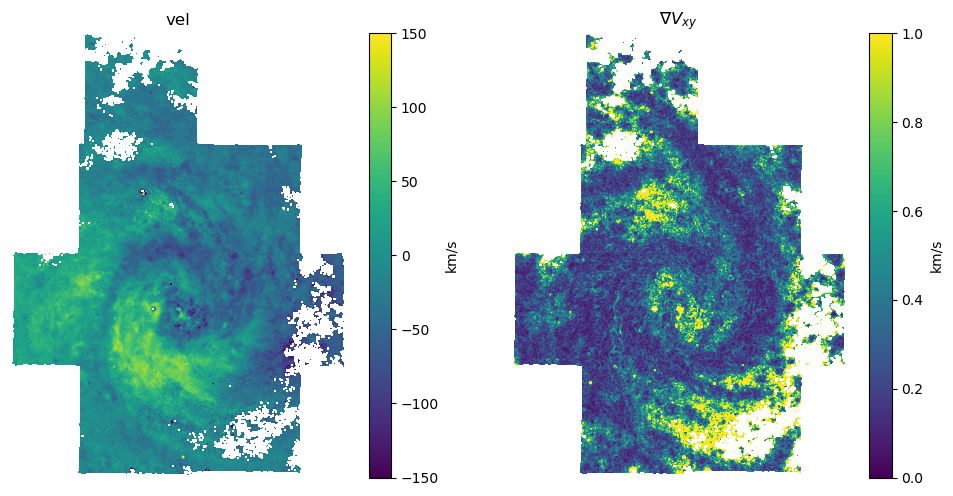

In [ ]:
grad_xy = calc_grad_xy(f"data/{galaxy_name}/{galaxy_name}_residuals.fits", dist)

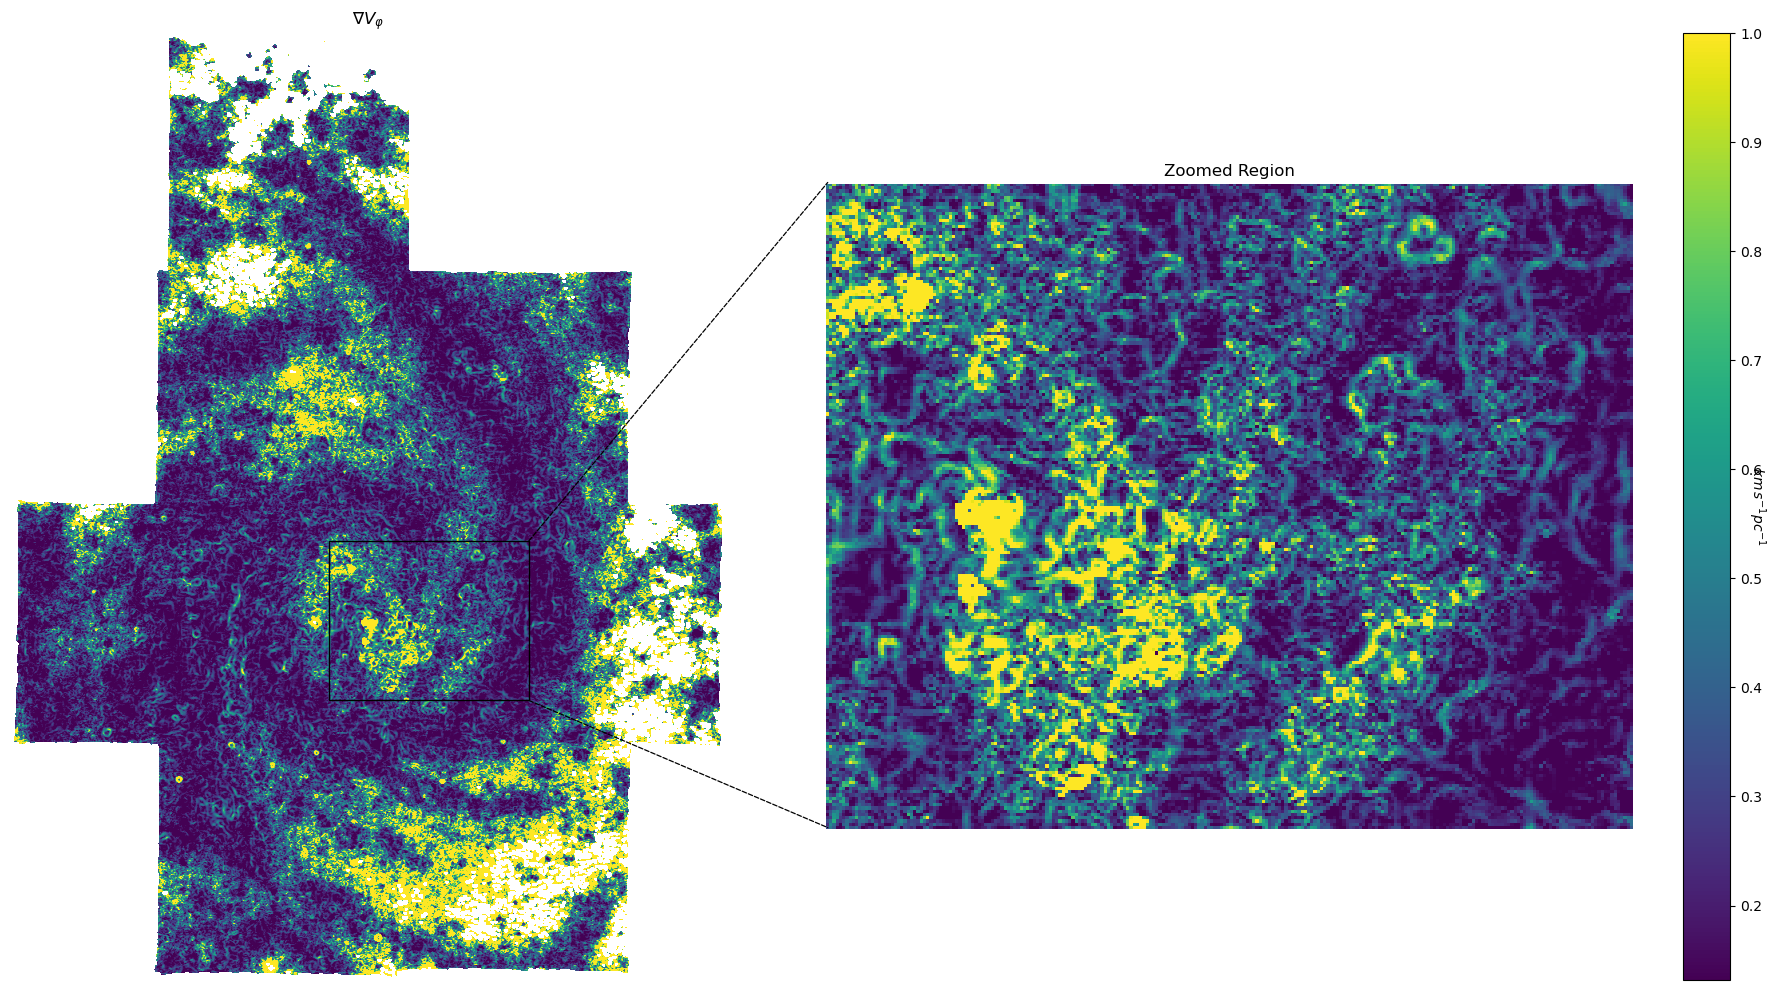

(<Figure size 2000x1000 with 3 Axes>,
 array([<Axes: title={'center': '$\\nabla V_{\\varphi}$'}>,
        <Axes: title={'center': 'Zoomed Region'}>], dtype=object),
 array([[0.32035295, 0.48423222, 0.39071818, ..., 0.1288613 , 0.22006599,
         0.36364169],
        [0.25205673, 0.53555984, 0.44139378, ..., 0.2189054 , 0.26608274,
         0.43621934],
        [0.33494524, 0.45103806, 0.67951522, ..., 0.26704818, 0.44831981,
         0.44536372],
        ...,
        [0.31836107, 0.31705825, 0.29834166, ..., 0.2160617 , 0.10054091,
         0.04829242],
        [0.45767241, 0.80095554, 0.31332383, ..., 0.2350995 , 0.15279884,
         0.07880972],
        [0.49292604, 0.49956594, 0.87417053, ..., 0.33332959, 0.25206077,
         0.09362233]]))

In [16]:
plot_with_zoom(grad_xy, (400, 350, 650, 550), norm_type="linear")

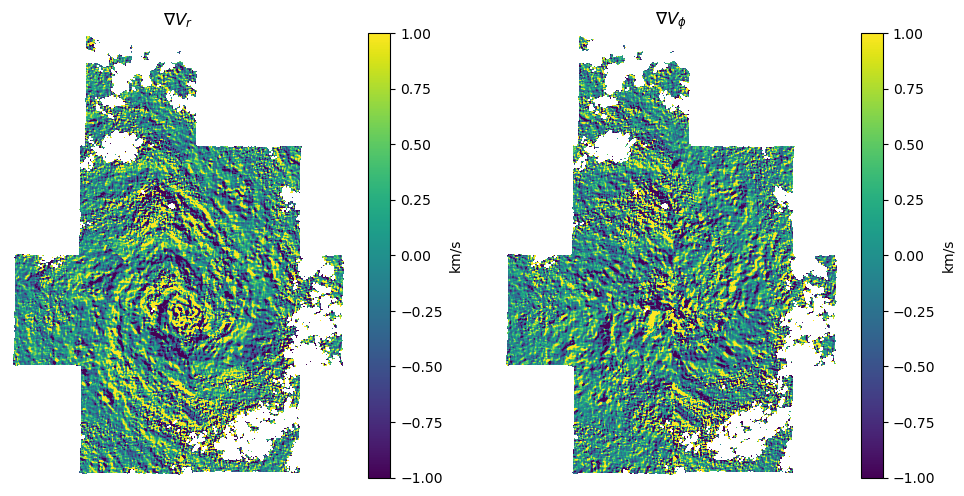

Galaxy name: NGC1566
Files saved.


In [17]:
grad_r, grad_phi = calc_grad_r_phi(f"data/{galaxy_name}/{galaxy_name}_residuals.fits", f"data/{galaxy_name}/{galaxy_name}_distance_map.fits", f"data/{galaxy_name}/{galaxy_name}_angle_map.fits", dist, size=5, save=True)


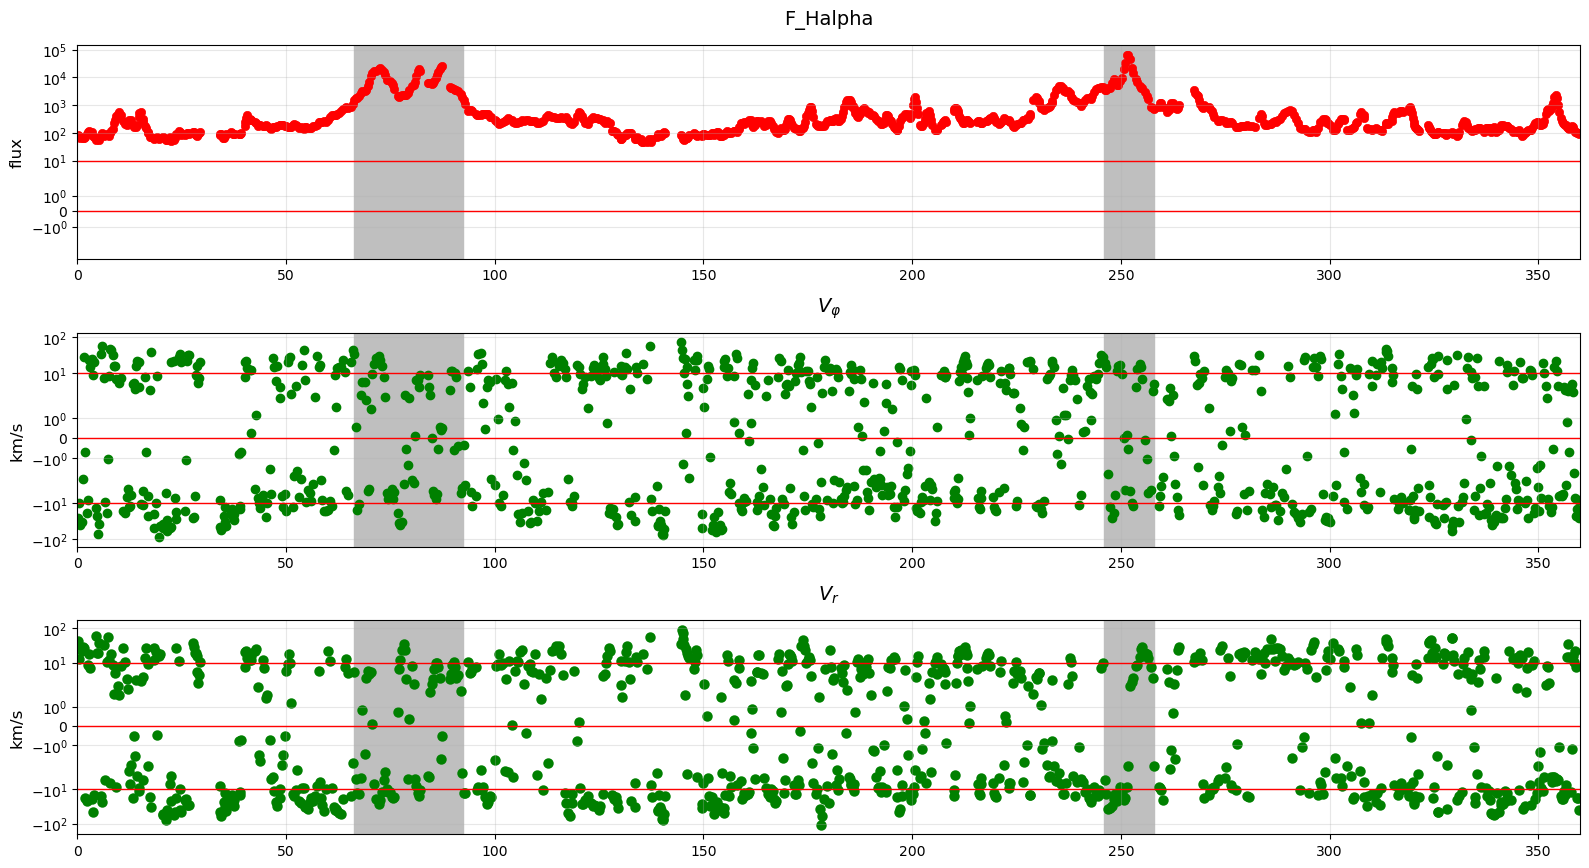

In [18]:
azimuthal_scan(f"data/F_Ha.fits", f"data/{galaxy_name}/{galaxy_name}_vel_grad_r.fits", f"data/{galaxy_name}/{galaxy_name}_vel_grad_phi.fits", f"data/{galaxy_name}/{galaxy_name}_angle_map.fits", f"data/{galaxy_name}/{galaxy_name}_distance_map.fits" )

In [36]:
! fitsheader "data/inputNGC1566/ngc1566_vel_Ha.fits"

# HDU 0 in data/inputNGC1566/ngc1566_vel_Ha.fits:
SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  898                                                  
NAXIS2  =                 1187                                                  
CD1_1   = -5.5555555555556E-05                                                  
CD2_2   =  5.5555555555556E-05                                                  
CRVAL1  =    65.00184639371101                                                  
CRVAL2  =     -54.937912051515                                                  
CRPIX1  =      451.21399818598                                                  
CRPIX2  =      447.31895706293                                                  
CUNIT1  = 'deg     '                                       

In [35]:
! fitsheader "data/inputNGC1566/ngc1566_radio_vel.fits"


# HDU 0 in data/inputNGC1566/ngc1566_radio_vel.fits:
SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  576                                                  
NAXIS2  =                  838                                                  
BMAJ    = 0.002083333333333333                                                  
BMIN    = 0.002083333333333333                                                  
BPA     =                  0.0                                                  
BTYPE   = 'Moment1 '                                                            
OBJECT  = 'NGC1566 '                                                            
BUNIT   = 'km s-1  '           / Brightness (pixel) unit                        
ALTRVAL =   2.293808490192E+11 /Alternate frequency refe

Starting velocity analysis for NGC1566
 data.shape = (838, 576)
Analysis completed. Results saved in data/NGC1566
shape of flux (838, 576), grad - (838, 576), (838, 576)
len of flux (3472,), grad - (3472,), (3472,)
Сохраняю 6 графиков в NGC1566_analysis.pdf
Ошибка при сохранении PDF: [WinError 32] Процесс не может получить доступ к файлу, так как этот файл занят другим процессом: 'NGC1566_analysis.pdf'


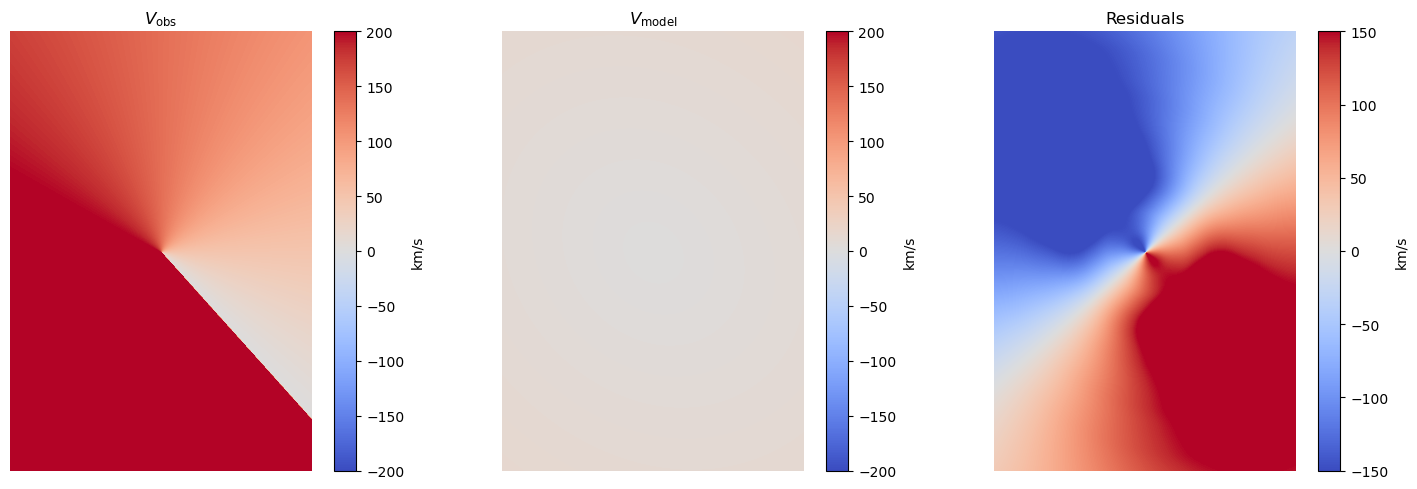

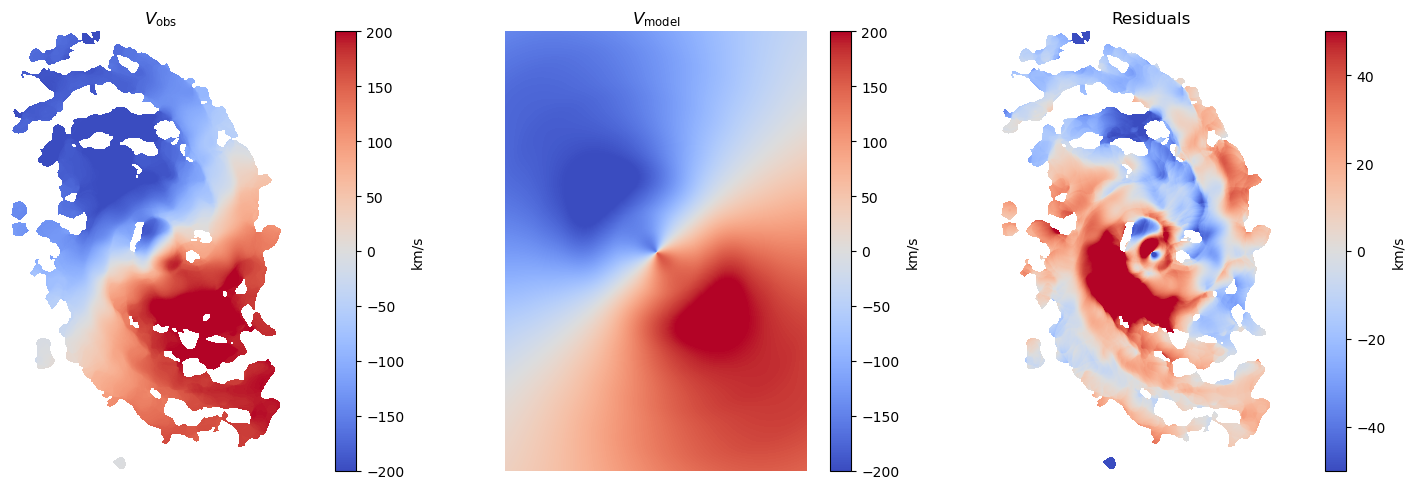

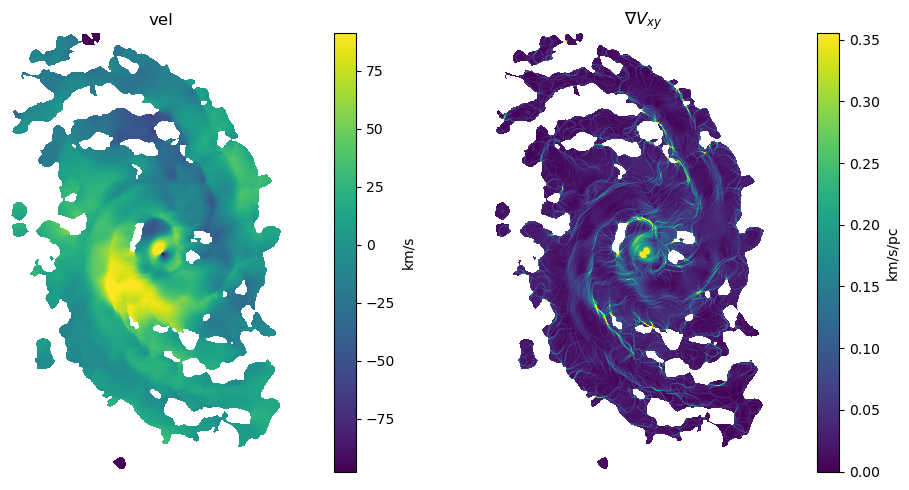

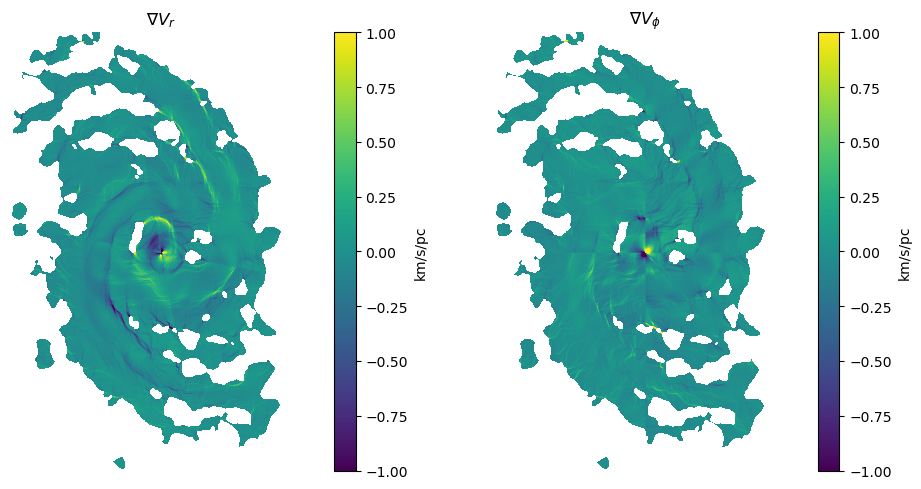

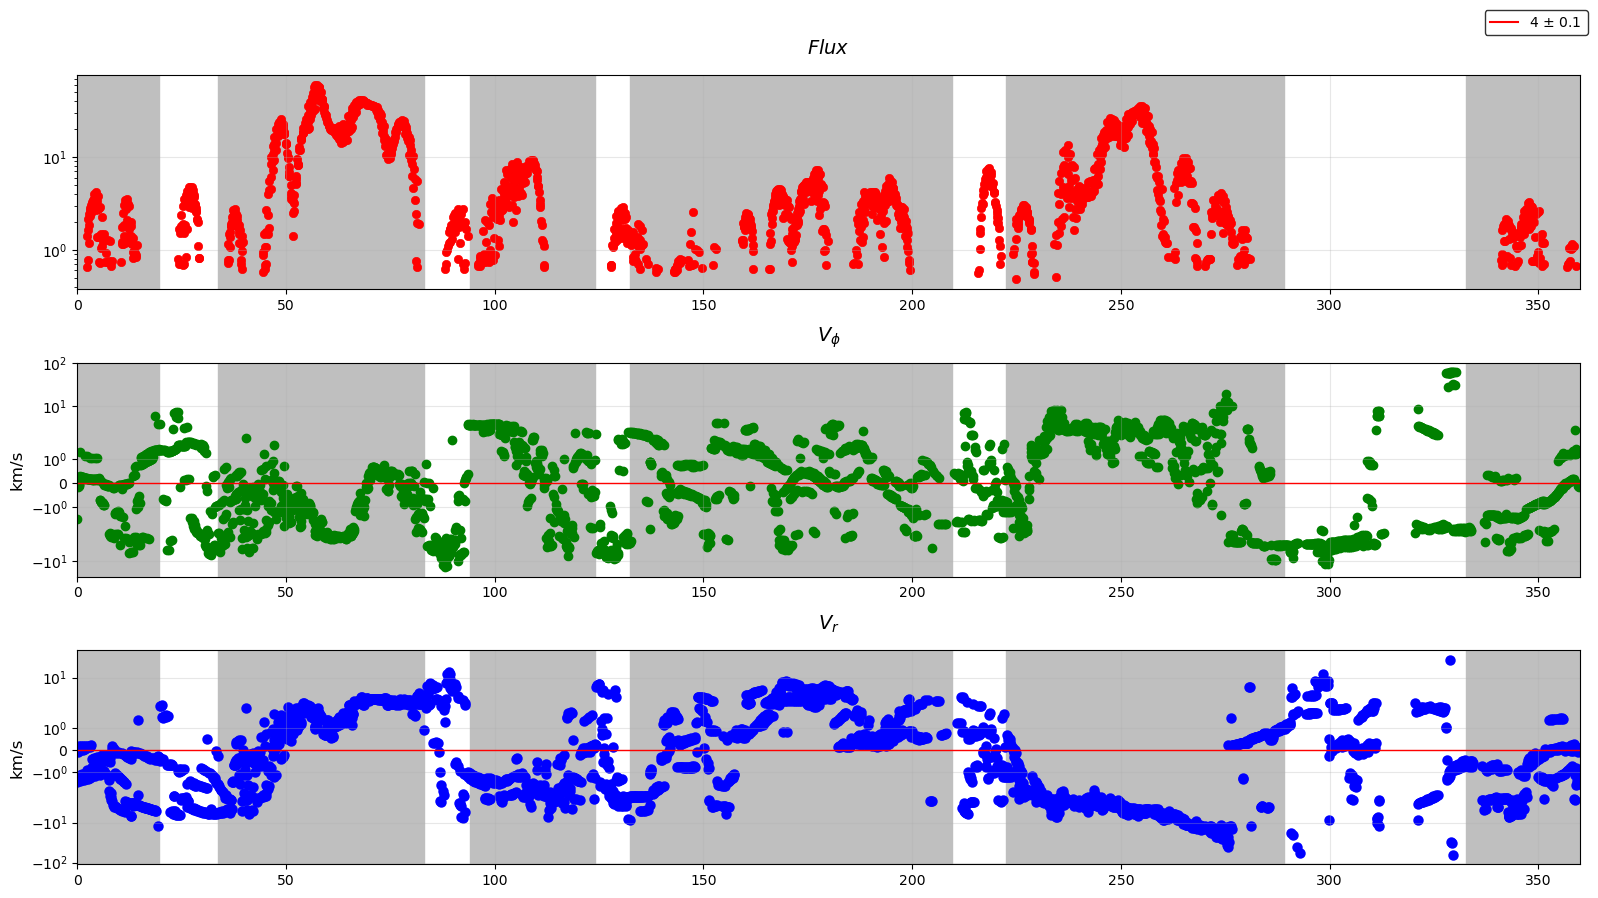

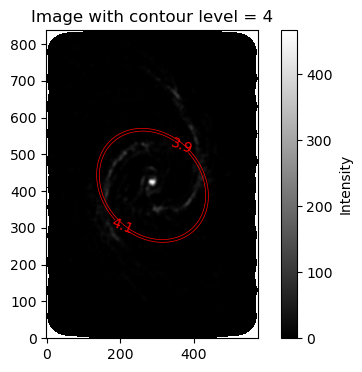

In [ ]:
import importlib
import gc
from astropy.io import fits

# Сначала импортируем модуль
import velocity_analysis
# ПЕРЕЗАГРУЗКА МОДУЛЯ
importlib.reload(velocity_analysis)
from velocity_analysis import run_velocity_analysis, run_gradient_analysis, run_azimuthal_analysis, plot_image_with_contour, save_to_pdf

# Параметры галактики
galaxy_name = "NGC1566"
telescop = "ALMA"
dist = 20.3
pa = 228
incl = 32
shift_vel = 1480
r = 4
bound = 0.1
scale_factor = None    # None or int

# Пути к файлам
velocity_file = f"data/input{galaxy_name}/{galaxy_name}_radio_vel.fits"
rad_file = f"data/input{galaxy_name}/{galaxy_name}_r1.npy"
circ_vel_file = f"data/input{galaxy_name}/{galaxy_name}_vel1.npy"
flux_file = f"data/input{galaxy_name}/F_CO.fits"

@save_to_pdf(f"{galaxy_name}_analysis.pdf")
def run_full_analysis():

    # Шаг 1: Анализ скоростей
    resid, model_vel_map, hdu = run_velocity_analysis(
        galaxy_name=galaxy_name,
        telescop=telescop,
        dist=dist,
        pa=pa,
        incl=incl,
        velocity_file=velocity_file,
        rad_file=rad_file,
        smooth=scale_factor,
        circ_vel_file=circ_vel_file,
        flux_file=flux_file,
        shift_vel=shift_vel,
        plot=True,
        save=False
    )

    # Шаг 2: Анализ градиентов
    # Теперь у нас в папке data/{galaxy_name} есть необходимые файлы: 
    # {galaxy_name}_residuals.fits, {galaxy_name}_distance_map.fits, {galaxy_name}_angle_map.fits

    # Формируем пути к сохраненным файлам
    import os
    data_dir = f"data/{galaxy_name}"
    velocity_residuals_file = os.path.join(data_dir, f"{galaxy_name}_{telescop}_residuals.fits")
    distance_map_file = os.path.join(data_dir, f"{galaxy_name}_{telescop}_distance_map.fits")
    angle_map_file = os.path.join(data_dir, f"{galaxy_name}_{telescop}_angle_map.fits")

    grad_xy, grad_r, grad_phi = run_gradient_analysis(
        galaxy_name=galaxy_name,
        telescop=telescop,
        dist=dist,
        velocity_file=velocity_residuals_file,
        distance_file=distance_map_file,
        angle_file=angle_map_file,
        PA = pa,
        plot=True,
        save=False, 
        shift_vel=shift_vel
    )

    # Шаг 3: Азимутальное сканирование
    # Теперь у нас есть градиенты, сохраненные в той же папке
    grad_r_file = os.path.join(data_dir, f"{galaxy_name}_{telescop}_vel_grad_r.fits")
    grad_phi_file = os.path.join(data_dir, f"{galaxy_name}_{telescop}_vel_grad_phi.fits")

    run_azimuthal_analysis(
        galaxy_name=galaxy_name,
        telescop=telescop,
        dist=dist,
        flux_file=flux_file,
        grad_r_file=grad_r_file,
        grad_phi_file=grad_phi_file,
        angle_file=angle_map_file,
        distance_file=distance_map_file,
        R=r,  # пример радиуса
        bound=bound
    )


    plot_image_with_contour(flux_file, distance_map_file, r, bound=bound, percent=99)

    # Принудительный сбор мусора (может помочь)
    gc.collect()

    # Проверка открытых файлов (если нужно)
    for obj in gc.get_objects():
        if isinstance(obj, fits.HDUList):
            print(f"Найден открытый HDUList: {obj}")
            obj.close()

run_full_analysis()


In [43]:
from matplotlib.backends.backend_pdf import PdfPages

def save_image(filename):
  # PdfPages is a wrapper around pdf
  # file so there is no clash and create
  # files with no error.
    with PdfPages(filename) as p:

        # get_fignums Return list of existing
        # figure numbers
        fig_nums = plt.get_fignums()
        figs = [plt.figure(n) for n in fig_nums]

        # iterating over the numbers in list
        for fig in figs:

            # and saving the files
            print("ggggg")
            fig.savefig(p, format='pdf')
            plt.close(fig)



save_image("NGC1566_ALMA.pdf")

C:\Users\kpoli\AppData\Local\Temp\ipykernel_13476\595195118.py:7: MatplotlibDeprecationWarning: Keeping empty pdf files is deprecated since 3.8 and support will be removed two minor releases later.
  with PdfPages(filename) as p:


In [78]:
gc.collect()

# Проверка открытых файлов (если нужно)
for obj in gc.get_objects():
    if isinstance(obj, fits.HDUList):
        print(f"Найден открытый HDUList: {obj}")
        obj.close()

Найден открытый HDUList: [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x000001EE05855370>]


In [8]:
from velocity_analysis import plot_image_with_contour

hdu_dust = fits.open("data/inputNGC1566/hlsp_phangs-jwst_jwst_miri_ngc1566_f770w_v1p0_img.fits", memmap=False)[0]
hdu_UV = fits.open("data/inputNGC1566/NGC_1566_I_FUV_g2006.fits",  memmap=False)[0]

hdu_dust.header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
DATE    = '2023-11-18T10:53:45.212' / UTC date file created                     
ORIGIN  = 'STSCI   '           / Organization responsible for creating file     
TIMESYS = 'UTC     '           / principal time system for time-related keywords
TIMEUNIT= 's       '           / Default unit applicable to all time values     
FILENAME= 'ngc1566_miri_lv3_f770w_i2d_align.fits' / Name of the file            
SDP_VER = '2023_2a '           / Data processing (DP) Software Version          
PRD_VER = 'PRDOPSSOC-063'      / S&OC Project Reference Database (PRD) Version  
OSS_VER = '8.4.14  '           / Observatory Scheduling Software (OSS) Version  
GSC_VER = 'GSC2431 '        

In [23]:
from astropy.wcs import WCS
from astropy.io import fits

with fits.open("data/NGC1566/NGC1566_VLT_MUSE_vel_grad_xy.fits") as hdul:
    # Просто создать WCS объект
    print(hdul[0].data.shape)
    wcs = WCS(hdul[0].header)  # или другого расширения с данными
    # Посмотрим, что внутри WCS
    print("WCS содержимое:")
    print("WCS атрибуты:")
    print(f"wcs.cd: {wcs.wcs.cd}")        # Матрица CD
    print(f"wcs.cdelt: {wcs.wcs.cdelt}")  # Значения CDELT
    # print(f"wcs.pc: {wcs.wcs.pc}")              # Матрица PC
    
    # Масштаб будет вычислен автоматически
    pixel_scales = wcs.proj_plane_pixel_scales()
    print(f"Масштаб пикселя: {pixel_scales[0]} x {pixel_scales[1]} ")

(1187, 898)
WCS содержимое:
WCS атрибуты:
wcs.cd: [[-5.55555556e-05  0.00000000e+00]
 [ 0.00000000e+00  5.55555556e-05]]
wcs.cdelt: [1. 1.]
Масштаб пикселя: 5.5555555555556e-05 deg x 5.5555555555556e-05 deg 


C:\Users\kpoli\AppData\Local\Temp\ipykernel_1944\1842308219.py:12: RuntimeWarning: cdelt will be ignored since cd is present
  print(f"wcs.cdelt: {wcs.wcs.cdelt}")  # Значения CDELT
